In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pickle
import sys

repo_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/"
sys.path.append(repo_path)

import thesis.code.online_quality_and_celltype.utils as ut

In [4]:
from thesis.code.plot import plot as plotter

plotter.set_default_params(kind='paper')

# load data

In [3]:
data_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype"


data_dir = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/online_quality_and_celltype"

# Load quality, traces, celltypes and online2offline mapping
with open(os.path.join(data_dir, "quality_df.pkl"), "rb") as f:
    quality_df = pickle.load(f)

with open(os.path.join(data_dir, "traces_df.pkl"), "rb") as f:
    traces_df = pickle.load(f)

with open(os.path.join(data_dir, "celltypes_df.pkl"), "rb") as f:
    celltypes_df = pickle.load(f)

with open(os.path.join(data_dir, "online2offline_celltype_df.pkl"), "rb") as f:
    online2offline_celltype_df = pickle.load(f)

with open(os.path.join(data_dir, "all_roi_masks.pkl"), "rb") as f:
    all_roi_masks = pickle.load(f)

# Print shapes to verify loading
print(f"Quality dataframe: {quality_df.shape}")
print(f"Traces dataframe: {traces_df.shape}")
print(f"Cell types dataframe: {celltypes_df.shape}")
print(f"Online to offline mapping: {online2offline_celltype_df.shape}")
print(f"ROI masks: {all_roi_masks.shape}")



Quality dataframe: (3873, 15)
Traces dataframe: (7748, 16)
Cell types dataframe: (3873, 18)
Online to offline mapping: (1849, 9)
ROI masks: (40, 11)


# Simulation calculation

# figures

In [6]:
quality_df.head()

,experimenter,date,exp_num,raw_id,field,region,cond1,stim_name_mb,cond2,roi_id,preprocess_id,stim_name_chirp,mb_qidx,chirp_qidx,field_id
0,closedlooptest,2025-03-19,1,1,GCL1,LR,cl,movingbar,control,1,1,gChirp,0.454855,0.333751,closedlooptest_2025-03-19_1_1_GCL1_LR
1,closedlooptest,2025-03-19,1,1,GCL1,LR,cl,movingbar,control,2,1,gChirp,0.415537,0.284353,closedlooptest_2025-03-19_1_1_GCL1_LR
2,closedlooptest,2025-03-19,1,1,GCL1,LR,cl,movingbar,control,3,1,gChirp,0.487898,0.470504,closedlooptest_2025-03-19_1_1_GCL1_LR
3,closedlooptest,2025-03-19,1,1,GCL1,LR,cl,movingbar,control,4,1,gChirp,0.574072,0.558473,closedlooptest_2025-03-19_1_1_GCL1_LR
4,closedlooptest,2025-03-19,1,1,GCL1,LR,cl,movingbar,control,5,1,gChirp,0.479788,0.400016,closedlooptest_2025-03-19_1_1_GCL1_LR


In [29]:
import importlib
importlib.reload(ut)

<module 'thesis.code.online_quality_and_celltype.utils' from '/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/code/online_quality_and_celltype/utils.py'>

cond1,cl,n1
field_id,,
closedlooptest_2025-03-19_1_1_GCL1_LR,0.692308,0.673267
closedlooptest_2025-03-19_2_1_GCL1_RR,0.880435,0.877358
closedlooptest_2025-03-19_2_1_GCL3_RR,0.802469,0.831325
closedlooptest_2025-03-19_2_1_GCL4_RR,0.681319,0.708333
closedlooptest_2025-03-19_2_1_GCL5_RR,0.791209,0.698113
closedlooptest_2025-03-19_2_1_GCL6_RR,0.548387,0.521368
closedlooptest_2025-03-21_1_1_GCL1_LR,0.828283,0.803150
closedlooptest_2025-03-21_1_1_GCL2_LR,0.802083,0.719008
closedlooptest_2025-03-21_1_1_GCL3_LR,0.895349,0.841463


In [ ]:
quality_pivot = ut.apply_func_and_pivot(quality_df,func=ut.frac_passing_or)

def plot_quality_scatter(quality_pivot):
 
    fig,ax = plt.subplots()
    ax.scatter(quality_pivot['n1'], quality_pivot['cl'], alpha=0.7)

    max_val = max(quality_pivot['n1'].max(), quality_pivot['cl'].max())
    min_val = min(quality_pivot['n1'].min(), quality_pivot['cl'].min())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5)

    ax.set_xlabel('Offline Quality')
    ax.set_ylabel('Online Quality')
    ax.set_title('Online vs Offline Quality')

    plt.axis('square')
    plt.xlim(min_val-0.05, max_val+0.05)
    plt.ylim(min_val-0.05, max_val+0.05)


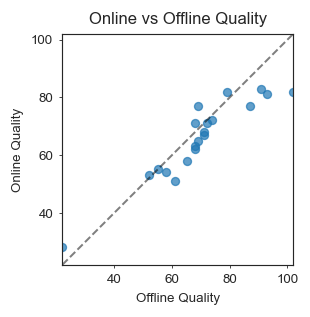

In [46]:
quality_pivot = ut.apply_func_and_pivot(quality_df,func=ut.nr_passing_or)
plot_quality_scatter(quality_pivot)

In [58]:
pd.qcut(quality_pivot['n1'], q=[0,1/3,2/3,1], labels=["bad","medium","good"]).reset_index()["n1"]

0        bad
1       good
2     medium
3        bad
4       good
5        bad
6       good
7       good
8     medium
9        bad
10       bad
11      good
12       bad
13      good
14       bad
15    medium
16      good
17    medium
18       bad
19       bad
Name: n1, dtype: category
Categories (3, object): ['bad' < 'medium' < 'good']

In [59]:
def add_terciles(quality_pivot):
    quality_pivot['n1_tercile'] = pd.qcut(quality_pivot['n1'], q=[0,1/3,2/3,1], labels=["bad","medium","good"])
    quality_pivot['cl_tercile'] = pd.qcut(quality_pivot['cl'], q=[0,1/3,2/3,1], labels=["bad","medium","good"])
    return quality_pivot
quality_pivot = add_terciles(quality_pivot)
quality_pivot.head()

cond1,cl,n1,n1_tercile,cl_tercile
field_id,,,,
closedlooptest_2025-03-19_1_1_GCL1_LR,63,68,bad,medium
closedlooptest_2025-03-19_2_1_GCL1_RR,81,93,good,good
closedlooptest_2025-03-19_2_1_GCL3_RR,65,69,medium,medium
closedlooptest_2025-03-19_2_1_GCL4_RR,62,68,bad,bad
closedlooptest_2025-03-19_2_1_GCL5_RR,72,74,good,good


In [65]:
counts_crosstab = pd.crosstab(quality_pivot['cl_tercile'], quality_pivot['n1_tercile'])
prob_crosstab = counts_crosstab.div(counts_crosstab.sum(axis=1), axis=0)
prob_crosstab



n1_tercile,bad,medium,good
cl_tercile,,,
bad,1.000000,0.000000,0.000000
medium,0.333333,0.500000,0.166667
good,0.000000,0.142857,0.857143


<Axes: xlabel='n1_tercile', ylabel='cl_tercile'>

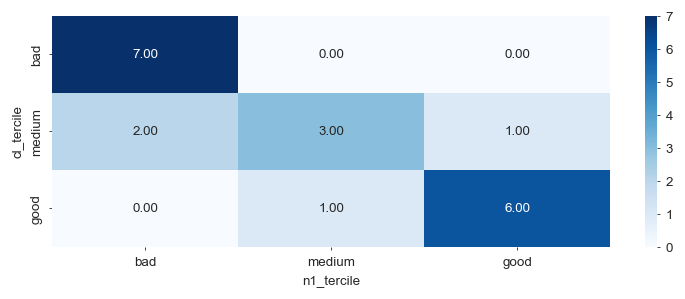

In [67]:
sns.heatmap(counts_crosstab, annot=True, fmt=".2f", cmap="Blues")

In [73]:
(online2offline_celltype_df["offline_cell_type"].eq(online2offline_celltype_df["online_cell_type"])).mean()

0.7079502433747972